# GraphCL Embeddings for Contig Binning

GraphCL learns embeddings by contrasting two augmented graph views. Here the views use feature masking and edge dropout over the assembly graph, plus marker cannot-link regularization.

This notebook runs the test dataset 10 times with different seeds, records all metrics for every run, prints min/max/mean/std, and plots mean metric values with standard-deviation error bars. Labels are used only after clustering to evaluate the bins. Node features use the RepBin-like representation: adjacency row + 136 TNF + coverage. The number of clusters is estimated from `contigs.fasta.markers`.

If dependencies are missing in a fresh environment, run:

```python
%pip install agtools torch scikit-learn biopython numpy pandas matplotlib scipy
```

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))

from graph_binning_common import *

DATA_DIR = REPO_ROOT / 'tests' / 'data'
SEED = 7
N_RUNS = 10
set_seed(SEED)


In [2]:
data = load_spades_dataset(DATA_DIR)
print_dataset_summary(data)

features = data['features']
adjacency = data['adjacency']
marker_pairs = data['marker_pairs']
labels = data['labels']
label_names = data['label_names']
N_CLUSTERS = data['marker_cluster_count']
print(f'k for clustering from marker genes: {N_CLUSTERS}')
print(f'marker cannot-link pairs: {len(marker_pairs)}')
print(data['feature_names'][:3], '...', data['feature_names'][-3:])


contigs: 509
edges: 1033
features: 646 (509 adjacency + 136 TNF + coverage)
marker sets: 91
marker-derived k: 5
Acetobacter_pasteurianus: 118
Aeromonas_veronii: 72
Amycolatopsis_mediterranei: 105
Arthrobacter_arilaitensis: 195
Azorhizobium_caulinodans: 19
k for clustering from marker genes: 5
marker cannot-link pairs: 1820
['adjacency_to_node_0', 'adjacency_to_node_1', 'adjacency_to_node_2'] ... ['TGCA', 'TTAA', 'log1p_coverage_zscore']


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

METHOD_NAME = 'GraphCL'

class GraphCLEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=96, embedding_dim=32, projection_dim=32, dropout=0.25):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim, bias=False)
        self.lin2 = nn.Linear(hidden_dim, embedding_dim, bias=False)
        self.projector = nn.Sequential(nn.Linear(embedding_dim, projection_dim), nn.ReLU(), nn.Linear(projection_dim, projection_dim))
        self.dropout = dropout

    def encode(self, x, adjacency):
        a_hat = normalized_adjacency(adjacency.numpy(), mode='symmetric')
        a_hat = torch.tensor(a_hat, dtype=torch.float32, device=x.device)
        h = F.relu(a_hat @ self.lin1(x))
        h = F.dropout(h, p=self.dropout, training=self.training)
        z = a_hat @ self.lin2(h)
        return F.normalize(z, p=2, dim=1)

    def forward(self, x, adjacency):
        z = self.encode(x, adjacency)
        return z, F.normalize(self.projector(z), p=2, dim=1)

def augment_graph(x, adj, rng, edge_drop=0.15, feature_drop=0.10):
    x_aug = x.clone()
    feature_mask = torch.tensor(rng.random(x.shape[1]) > feature_drop, dtype=torch.float32)
    x_aug = x_aug * feature_mask
    adj_aug = adj.clone()
    upper = np.transpose(np.triu_indices(adj.shape[0], k=1))
    keep = rng.random(len(upper)) > edge_drop
    drop_edges = upper[~keep]
    for i, j in drop_edges:
        if adj_aug[i, j] > 0:
            adj_aug[i, j] = 0
            adj_aug[j, i] = 0
    return x_aug, adj_aug

def graphcl_loss(p1, p2, temperature=0.5):
    logits = p1 @ p2.T / temperature
    targets = torch.arange(p1.shape[0])
    return 0.5 * (F.cross_entropy(logits, targets) + F.cross_entropy(logits.T, targets))

def train_graphcl(seed, epochs=250, patience=35, lr=0.005, constraint_weight=0.25):
    set_seed(seed)
    rng = np.random.default_rng(seed)
    x = torch.tensor(features, dtype=torch.float32)
    adj = torch.tensor(adjacency, dtype=torch.float32)
    pairs = torch.tensor(marker_pairs, dtype=torch.long) if len(marker_pairs) else None
    model = GraphCLEncoder(features.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    best_state, best_loss, wait = None, float('inf'), 0
    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad()
        x1, a1 = augment_graph(x, adj, rng)
        x2, a2 = augment_graph(x, adj, rng)
        z1, p1 = model(x1, a1)
        z2, p2 = model(x2, a2)
        loss = graphcl_loss(p1, p2)
        if pairs is not None:
            z = model.encode(x, adj)
            loss = loss + constraint_weight * torch.exp(-F.pairwise_distance(z[pairs[:, 0]], z[pairs[:, 1]], p=2)).mean()
        loss.backward()
        opt.step()
        current = float(loss.item())
        if current < best_loss - 1e-5:
            best_loss = current
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if wait >= patience:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        embeddings = model.encode(x, adj).cpu().numpy()
    return embeddings, {'epoch': epoch, 'loss': best_loss}

def run_once(seed):
    embeddings, history = train_graphcl(seed)
    predictions, metrics = run_kmeans(embeddings, labels, seed=seed, n_clusters=N_CLUSTERS)
    metrics.update({'epochs': history['epoch'], 'loss': history['loss']})
    return metrics


run 01 seed=7: precision=0.8998, recall=0.8703, f1=0.8848, ari=0.7229, nmi=0.7893
run 02 seed=8: precision=0.9371, recall=0.9371, f1=0.9371, ari=0.8390, nmi=0.8382
run 03 seed=9: precision=0.8723, recall=0.8566, f1=0.8644, ari=0.7029, nmi=0.7336
run 04 seed=10: precision=0.9253, recall=0.9253, f1=0.9253, ari=0.8615, nmi=0.8435
run 05 seed=11: precision=0.9371, recall=0.9371, f1=0.9371, ari=0.9005, nmi=0.8759
run 06 seed=12: precision=0.8802, recall=0.8428, f1=0.8611, ari=0.7137, nmi=0.7584
run 07 seed=13: precision=0.9273, recall=0.9273, f1=0.9273, ari=0.8745, nmi=0.8528
run 08 seed=14: precision=0.8507, recall=0.7760, f1=0.8116, ari=0.5811, nmi=0.6616
run 09 seed=15: precision=0.9312, recall=0.9312, f1=0.9312, ari=0.8168, nmi=0.8348
run 10 seed=16: precision=0.8939, recall=0.8939, f1=0.8939, ari=0.7393, nmi=0.7825


,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,1,7,0.899804,0.870334,0.884823,0.722917,0.789267,5,5,0.828747,250,4.486458
1,2,8,0.937132,0.937132,0.937132,0.839005,0.838180,5,5,0.946585,250,4.481864
2,3,9,0.872299,0.856582,0.864369,0.702880,0.733589,5,5,0.810985,250,4.480369
3,4,10,0.925344,0.925344,0.925344,0.861530,0.843527,5,5,0.872468,250,4.477888
4,5,11,0.937132,0.937132,0.937132,0.900504,0.875858,5,5,0.892742,250,4.494662
5,6,12,0.880157,0.842829,0.861089,0.713726,0.758419,5,5,0.791716,250,4.486057
6,7,13,0.927308,0.927308,0.927308,0.874484,0.852801,5,5,0.874548,250,4.488605
7,8,14,0.850688,0.776031,0.811646,0.581134,0.661647,5,5,0.746814,250,4.474556
8,9,15,0.931238,0.931238,0.931238,0.816779,0.834834,5,5,0.943198,250,4.474138
9,10,16,0.893910,0.893910,0.893910,0.739295,0.782456,5,5,0.909213,250,4.481161


,min,max,mean,std
precision,0.850688,0.937132,0.905501,0.030639
recall,0.776031,0.937132,0.889784,0.053247
f1,0.811646,0.937132,0.897399,0.042047
ari,0.581134,0.900504,0.775225,0.099725
nmi,0.661647,0.875858,0.797058,0.065596
aligned_macro_f1,0.746814,0.946585,0.861702,0.065916


<Axes: title={'center': 'GraphCL: mean metrics over 10 runs'}, ylabel='score'>

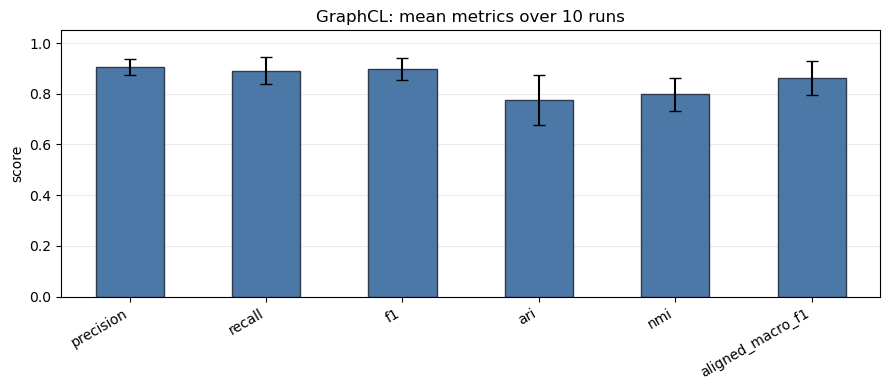

In [4]:
results = run_repeated_experiment(run_once, n_runs=N_RUNS, seed=SEED)
summary = summarize_metric_table(results)

display(results)
display(summary)
plot_metric_bars(summary, title=f'{METHOD_NAME}: mean metrics over {N_RUNS} runs')


## Assembly graph coloured by predicted bin

This plot reruns the method once on the original test graph using `SEED`, captures that method's KMeans bin assignments, and colours contigs in the igraph assembly graph by the predicted bin.

{'precision': 0.8958742632612967, 'recall': 0.8801571709233792, 'f1': 0.8879461724359754, 'ari': 0.733203385646919, 'nmi': 0.7876001957575823, 'n_bins_predicted': 5, 'n_true_bins': 5, 'aligned_macro_f1': 0.8418446421760759, 'epochs': 250, 'loss': 4.487429618835449}
GraphCL: assembly graph coloured by predicted bin
bin 0: 113 contigs
bin 1: 119 contigs
bin 2: 94 contigs
bin 3: 137 contigs
bin 4: 46 contigs


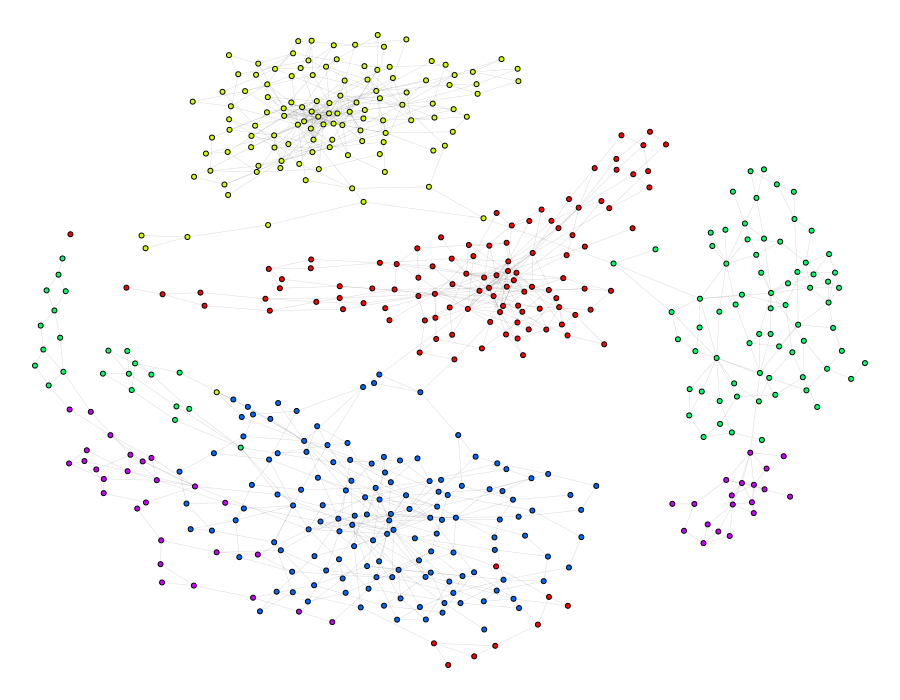

In [5]:
_visual_predictions = None
_original_run_kmeans = run_kmeans

def _capture_run_kmeans(embeddings, labels, seed=7, n_clusters=None):
    global _visual_predictions
    predictions, metrics = _original_run_kmeans(embeddings, labels, seed=seed, n_clusters=n_clusters)
    _visual_predictions = predictions
    return predictions, metrics

run_kmeans = _capture_run_kmeans
try:
    visual_metrics = run_once(SEED)
finally:
    run_kmeans = _original_run_kmeans

print(visual_metrics)
plot_assembly_graph_bins(
    data,
    bins=_visual_predictions,
    title=f'{METHOD_NAME}: assembly graph coloured by predicted bin',
)


## Graph corruption / ablation study

This section reruns the same method under five graph conditions: original assembly graph, random edge removal, random edge addition, coverage-similarity edges added, and short contigs removed. Each condition is run with the same 10 seeds, then metrics are summarized and plotted with standard-deviation error bars.

ablation: original assembly graph
ablation: random edge removal
ablation: random edge addition
ablation: coverage-similarity edges added
ablation: short contigs removed


,ablation,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,original assembly graph,1,7,0.895874,0.880157,0.887946,0.733203,0.787600,5,5,0.841845,250,4.487430
1,original assembly graph,2,8,0.927308,0.927308,0.927308,0.812342,0.838213,5,5,0.940154,250,4.483065
2,original assembly graph,3,9,0.868369,0.833006,0.850320,0.670185,0.715497,5,5,0.792178,213,4.489628
3,original assembly graph,4,10,0.911591,0.911591,0.911591,0.820645,0.853107,5,5,0.874588,250,4.477362
4,original assembly graph,5,11,0.937132,0.937132,0.937132,0.900504,0.875858,5,5,0.892742,250,4.494663
5,original assembly graph,6,12,0.891945,0.836935,0.863565,0.698036,0.758516,5,5,0.791148,250,4.485721
6,original assembly graph,7,13,0.927308,0.927308,0.927308,0.874484,0.852801,5,5,0.874548,250,4.488605
7,original assembly graph,8,14,0.866405,0.785855,0.824166,0.601005,0.678369,5,5,0.755968,250,4.474863
8,original assembly graph,9,15,0.933202,0.933202,0.933202,0.820900,0.842513,5,5,0.944969,250,4.472345
9,original assembly graph,10,16,0.891945,0.891945,0.891945,0.735588,0.778818,5,5,0.907313,250,4.481876


precision                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.866405  0.937132  0.905108  0.026081   
random edge removal              0.827112  0.923379  0.874460  0.030834   
random edge addition             0.791749  0.876228  0.846365  0.027424   
coverage-similarity edges added  0.740668  0.823183  0.789391  0.024129   
short contigs removed            0.831111  0.911111  0.862444  0.030729   

                                   recall                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.785855  0.937132  0.886444  0.051879   
random edge removal              0.752456  0.889980  0.840275  0.047937   
random edge addition             0.774067  0.856582  0.808644  0.028833   
coverage-similarity edges added  0.691552  0.797642  0.757564  0.033098   
short contigs removed            0.775556  0.893333  0.823778  0.042255   

                                       f1            ...       ari            \
                                      min       max  ...      mean       std   
ablation                                             ...                       
original assembly graph          0.824166  0.937132  ...  0.766689  0.094884   
random edge removal              0.794436  0.906372  ...  0.690758  0.074007   
random edge addition             0.789779  0.864369  ...  0.618817  0.049358   
coverage-similarity edges added  0.715268  0.803493  ...  0.523110  0.047990   
short contigs removed            0.807515  0.896654  ...  0.656296  0.070981   

                                      nmi                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.678369  0.875858  0.798129  0.065704   
random edge removal              0.641867  0.828841  0.739268  0.054101   
random edge addition             0.591139  0.712205  0.661122  0.037553   
coverage-similarity edges added  0.478530  0.579833  0.550386  0.029336   
short contigs removed            0.666718  0.793758  0.720205  0.048736   

                                aligned_macro_f1                                
                                             min       max      mean       std  
ablation                                                                        
original assembly graph                 0.755968  0.944969  0.861545  0.064849  
random edge removal                     0.723136  0.895018  0.808236  0.056998  
random edge addition                    0.736978  0.829818  0.770266  0.029920  
coverage-similarity edges added         0.644938  0.755512  0.705941  0.033466  
short contigs removed                   0.738373  0.869599  0.794404  0.049923  

[5 rows x 24 columns]

<Axes: title={'center': 'GraphCL: graph corruption / ablation study'}, xlabel='ablation', ylabel='score'>

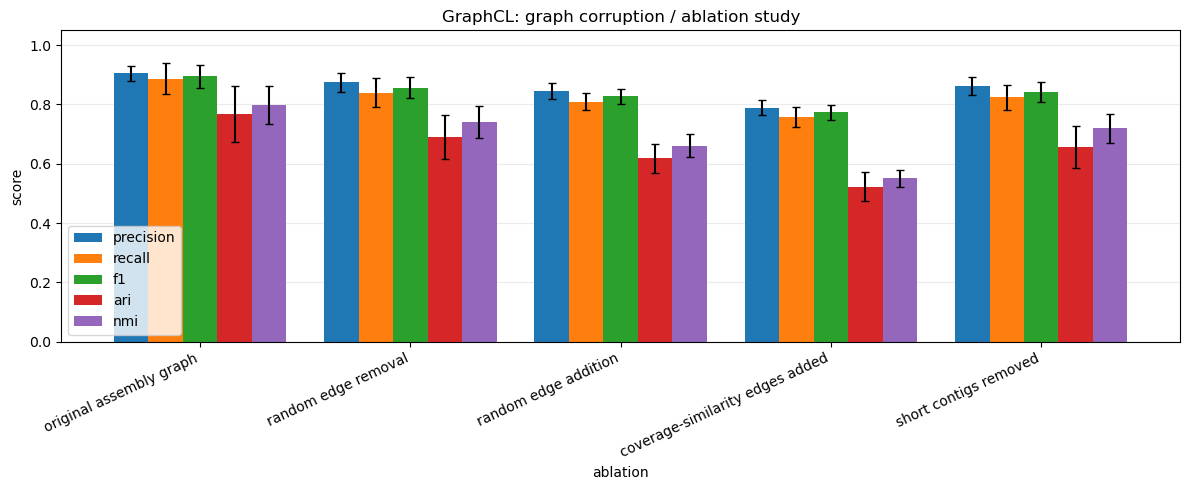

In [6]:
def run_once_ablation(seed, ablation_data):
    global features, adjacency, marker_pairs, labels, label_names, N_CLUSTERS, spectral_embeddings

    old_state = {
        'features': features,
        'adjacency': adjacency,
        'marker_pairs': marker_pairs,
        'labels': labels,
        'label_names': label_names,
        'N_CLUSTERS': N_CLUSTERS,
        'spectral_embeddings': globals().get('spectral_embeddings', None),
    }
    try:
        features = ablation_data['features']
        adjacency = ablation_data['adjacency']
        marker_pairs = ablation_data['marker_pairs']
        labels = ablation_data['labels']
        label_names = ablation_data['label_names']
        N_CLUSTERS = ablation_data['marker_cluster_count']

        # The Laplacian Eigenmaps notebook precomputes graph embeddings outside
        # run_once, so recompute them when the graph changes.
        if 'laplacian_eigenmap_embeddings' in globals():
            spectral_embeddings = laplacian_eigenmap_embeddings(adjacency, dimensions=32)

        return run_once(seed)
    finally:
        features = old_state['features']
        adjacency = old_state['adjacency']
        marker_pairs = old_state['marker_pairs']
        labels = old_state['labels']
        label_names = old_state['label_names']
        N_CLUSTERS = old_state['N_CLUSTERS']
        if old_state['spectral_embeddings'] is not None:
            spectral_embeddings = old_state['spectral_embeddings']

ablation_results, ablation_summary = run_graph_ablation_study(
    data,
    run_once_ablation,
    n_runs=N_RUNS,
    seed=SEED,
)

display(ablation_results)
display(ablation_summary)
plot_ablation_metric_bars(ablation_summary, title=f'{METHOD_NAME}: graph corruption / ablation study')
